In [1]:
import glob
import os
import string

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device is set to: {device}")

Device is set to: cuda


### Load Data

The names can be found in text files in a src directory, one file per language.

In the following you can find some utilities to load the data into pandas data frames. 

We will restrict to some common European languages. 

With the given selection, we will identify all the occurring characters and initialize an alphabet.<br>
For this alphabet, we will use a one-hot-encoding to map them into a vector space representation. 

Foresee a suitable character for the end of the word, e.g. 'END'.

In [3]:
srcdir = 'data/names'
languages = ["English","French","Italian","German","Spanish"]

In [4]:
# inspect the data directory
def findFiles(path): 
    return glob.glob(path)

In [5]:
print('\n'.join(findFiles(os.path.join(srcdir,'*.txt'))))

data/names\Arabic.txt
data/names\Chinese.txt
data/names\Czech.txt
data/names\Dutch.txt
data/names\English.txt
data/names\French.txt
data/names\German.txt
data/names\Greek.txt
data/names\Irish.txt
data/names\Italian.txt
data/names\Japanese.txt
data/names\Korean.txt
data/names\Polish.txt
data/names\Portuguese.txt
data/names\Russian.txt
data/names\Scottish.txt
data/names\Spanish.txt
data/names\Vietnamese.txt


In [6]:
# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return lines

def load_data(srcdir, categories=None):
    names_list = []
    for filename in findFiles(os.path.join(srcdir,'*.txt')):
        category = os.path.splitext(os.path.basename(filename))[0]
        if not categories or category in categories: 
            names = readLines(filename)
            names_list.extend([(name,category) for name in names])
    df = pd.DataFrame(names_list)
    df.columns = ["name","lang"]
    return df

In [7]:
names = load_data(srcdir,categories=languages)
names.head()

,name,lang
0,Abbas,English
1,Abbey,English
2,Abbott,English
3,Abdi,English
4,Abel,English


In [8]:
maxlen = np.max([len(name) for name in names.name])
print("Maximum name length: ", maxlen)

Maximum name length:  18


In [9]:
alphabet = sorted(list(set(''.join([name for name in names.name]))))
alphabet.append('END')
len_alphabet = len(alphabet)
char_index = dict((c, i) for i, c in enumerate(alphabet))
print("Size of alphabet: ",len_alphabet)
print(alphabet)

Size of alphabet:  74
[' ', "'", 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'Á', 'É', 'ß', 'à', 'á', 'ä', 'ç', 'è', 'é', 'ê', 'ì', 'í', 'ñ', 'ò', 'ó', 'ö', 'ù', 'ú', 'ü', 'END']


In [10]:
names.groupby('lang')['name'].count()/len(names)

lang
English    0.646230
French     0.048802
German     0.127555
Italian    0.124912
Spanish    0.052502
Name: name, dtype: float64

### Vector Representations

Now construct the vector representation by using one-hot-vectors. 

In [11]:
language_to_index = {country:index for index,country in enumerate(names.lang.unique())}
index_to_language = {index:country for index,country in enumerate(names.lang.unique())}

def onehot(i, length):
    v = np.zeros(length)
    v[i] = 1
    return v

def name_representation(name, maxlen):
    ### START YOUR CODE
    name_trunc = str(name)[0:maxlen]
    size = len(char_index)
    vector = [onehot(char_index[j], size) for j in str(name)]
    # fill the rest with 
    for k in range(0,maxlen - len(str(name))):
        vector.append(onehot(char_index['END'], size))
    return vector
    ### START YOUR CODE

def lang_representation(language, language_to_index):
    y = np.zeros(len(language_to_index))
    y[language_to_index[language]]=1
    return y

def lang_from_output(score):
    return index_to_language[np.argmax(score)]

def predict(name, model):
    score = model.predict(np.array([name_representation(name, maxlen)]))[0]
    return lang_from_output(score)

### Prepare train/val

Split the data into train/val

Shuffle the data

Transform the names data into a suitable vector respresentation:
* names into numpy arrays of shape (*,maxlen,len_alphabet)
* language into numpy array of shape (*,len(languages))



In [12]:
val_split = 0.2

### START YOUR CODE
# Shuffle and split names data
names = names.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the data

names['name'] = names['name'].apply(lambda x: name_representation(x, maxlen))
names['lang'] = names['lang'].apply(lambda x: lang_representation(x, language_to_index))

val_size = int(len(names) * val_split)

val = names.iloc[:val_size]
train = names.iloc[val_size:]
### END YOUR CODE

In [13]:
print(f"Train shape: {train.shape}")
print(f"Val shape: {val.shape}")

Train shape: (4541, 2)
Val shape: (1135, 2)


In [14]:
names

,name,lang
0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[1.0, 0.0, 0.0, 0.0, 0.0]"
1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0,...","[1.0, 0.0, 0.0, 0.0, 0.0]"
2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[1.0, 0.0, 0.0, 0.0, 0.0]"
3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[1.0, 0.0, 0.0, 0.0, 0.0]"
4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 1.0, 0.0]"
...,...,...
5671,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[0.0, 1.0, 0.0, 0.0, 0.0]"
5672,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 1.0, 0.0]"
5673,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 1.0, 0.0]"
5674,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 1.0]"


In [15]:
### START YOUR CODE

# Map train and val data into vector space (one-hot-vectors)
X_train = torch.tensor(train['name'].tolist(), dtype=torch.float32)
y_train = torch.tensor(train['lang'].tolist(), dtype=torch.float32)

X_val = torch.tensor(val['name'].tolist(), dtype=torch.float32)
y_val = torch.tensor(val['lang'].tolist(), dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
### END YOUR CODE

C:\Users\micha\AppData\Local\Temp\ipykernel_10476\2167078831.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X_train = torch.tensor(train['name'].tolist(), dtype=torch.float32)


Possibly, pack the data into a Dataset (e.g. when working with in PyTorch)

### Define and Train Model: Single Layer with SimpleRNN

Create an RNN consisting of a single layer with a SimpleRNN (keras) and a softmax.

Then train the model. Play with different number of hidden units in the layer to obtain a good accuracy.

In [16]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True, num_layers=num_layers)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, hidden = self.rnn(x)
        out = self.fc(hidden[-1])
        return out

In [25]:
def run_epoch(model, dataloader, optimizer, criterion, train=True):
    """
    Runs one epoch for training or validation.
    """
    epoch_loss = 0
    correct = 0
    total_samples = len(dataloader.dataset)
    total_preds = []
    total_targets = []

    if train:
        model.train()
    else:
        model.eval()

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            output = model(X)
            loss = criterion(output, y)

        epoch_loss += loss.item()
        _, y_pred = torch.max(output, dim=1)
        correct += torch.sum(y_pred == torch.argmax(y, dim=1)).item()

        if train:
            loss.backward()
            optimizer.step()
        else:
            total_preds.append(y_pred.detach().cpu())
            total_targets.append(torch.argmax(y, dim=1).detach().cpu())

    avg_loss = epoch_loss / len(dataloader)
    accuracy = correct / total_samples

    return avg_loss, accuracy, total_preds, total_targets

def trainer(model, train_loader, val_loader, optimizer, criterion, n_epochs, verbose=True):
    """
    Trains and evaluates the model for n_epochs.
    """
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_accs = []
    epoch_val_accs = []
    total_preds, total_targets = None, None

    for epoch in range(n_epochs):

        if verbose:
            print(f'\nEpoch {epoch+1}/{n_epochs}')
            print('----------')

        train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_loss, val_acc, total_preds, total_targets = run_epoch(model, val_loader, optimizer, criterion, train=False)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_train_accs.append(train_acc)
        epoch_val_accs.append(val_acc)

        if verbose or epoch % 10 == 0:
            print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}\nVal Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}')

    return epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs, total_preds, total_targets

Run 1 with batch_size 128 and hidden_size 128.
Train Loss: 1.2014, Train Accuracy: 0.5983
Val Loss: 1.1278, Val Accuracy: 0.6379
Train Loss: 0.8694, Train Accuracy: 0.7126
Val Loss: 0.9031, Val Accuracy: 0.6749
Train Loss: 0.6897, Train Accuracy: 0.7608
Val Loss: 0.7034, Val Accuracy: 0.7542
Train Loss: 0.5809, Train Accuracy: 0.7890
Val Loss: 0.7042, Val Accuracy: 0.7542
Train Loss: 0.5363, Train Accuracy: 0.8029
Val Loss: 0.6224, Val Accuracy: 0.7815
Run 2 with batch_size 256 and hidden_size 128.
Train Loss: 1.2374, Train Accuracy: 0.6483
Val Loss: 1.1577, Val Accuracy: 0.6379
Train Loss: 0.9013, Train Accuracy: 0.6921
Val Loss: 0.9067, Val Accuracy: 0.6899
Train Loss: 0.8009, Train Accuracy: 0.7296
Val Loss: 0.8006, Val Accuracy: 0.7278
Train Loss: 0.7197, Train Accuracy: 0.7509
Val Loss: 0.7543, Val Accuracy: 0.7348
Train Loss: 0.6656, Train Accuracy: 0.7564
Val Loss: 0.7112, Val Accuracy: 0.7436
Run 3 with batch_size 512 and hidden_size 128.
Train Loss: 1.3165, Train Accuracy: 0.6

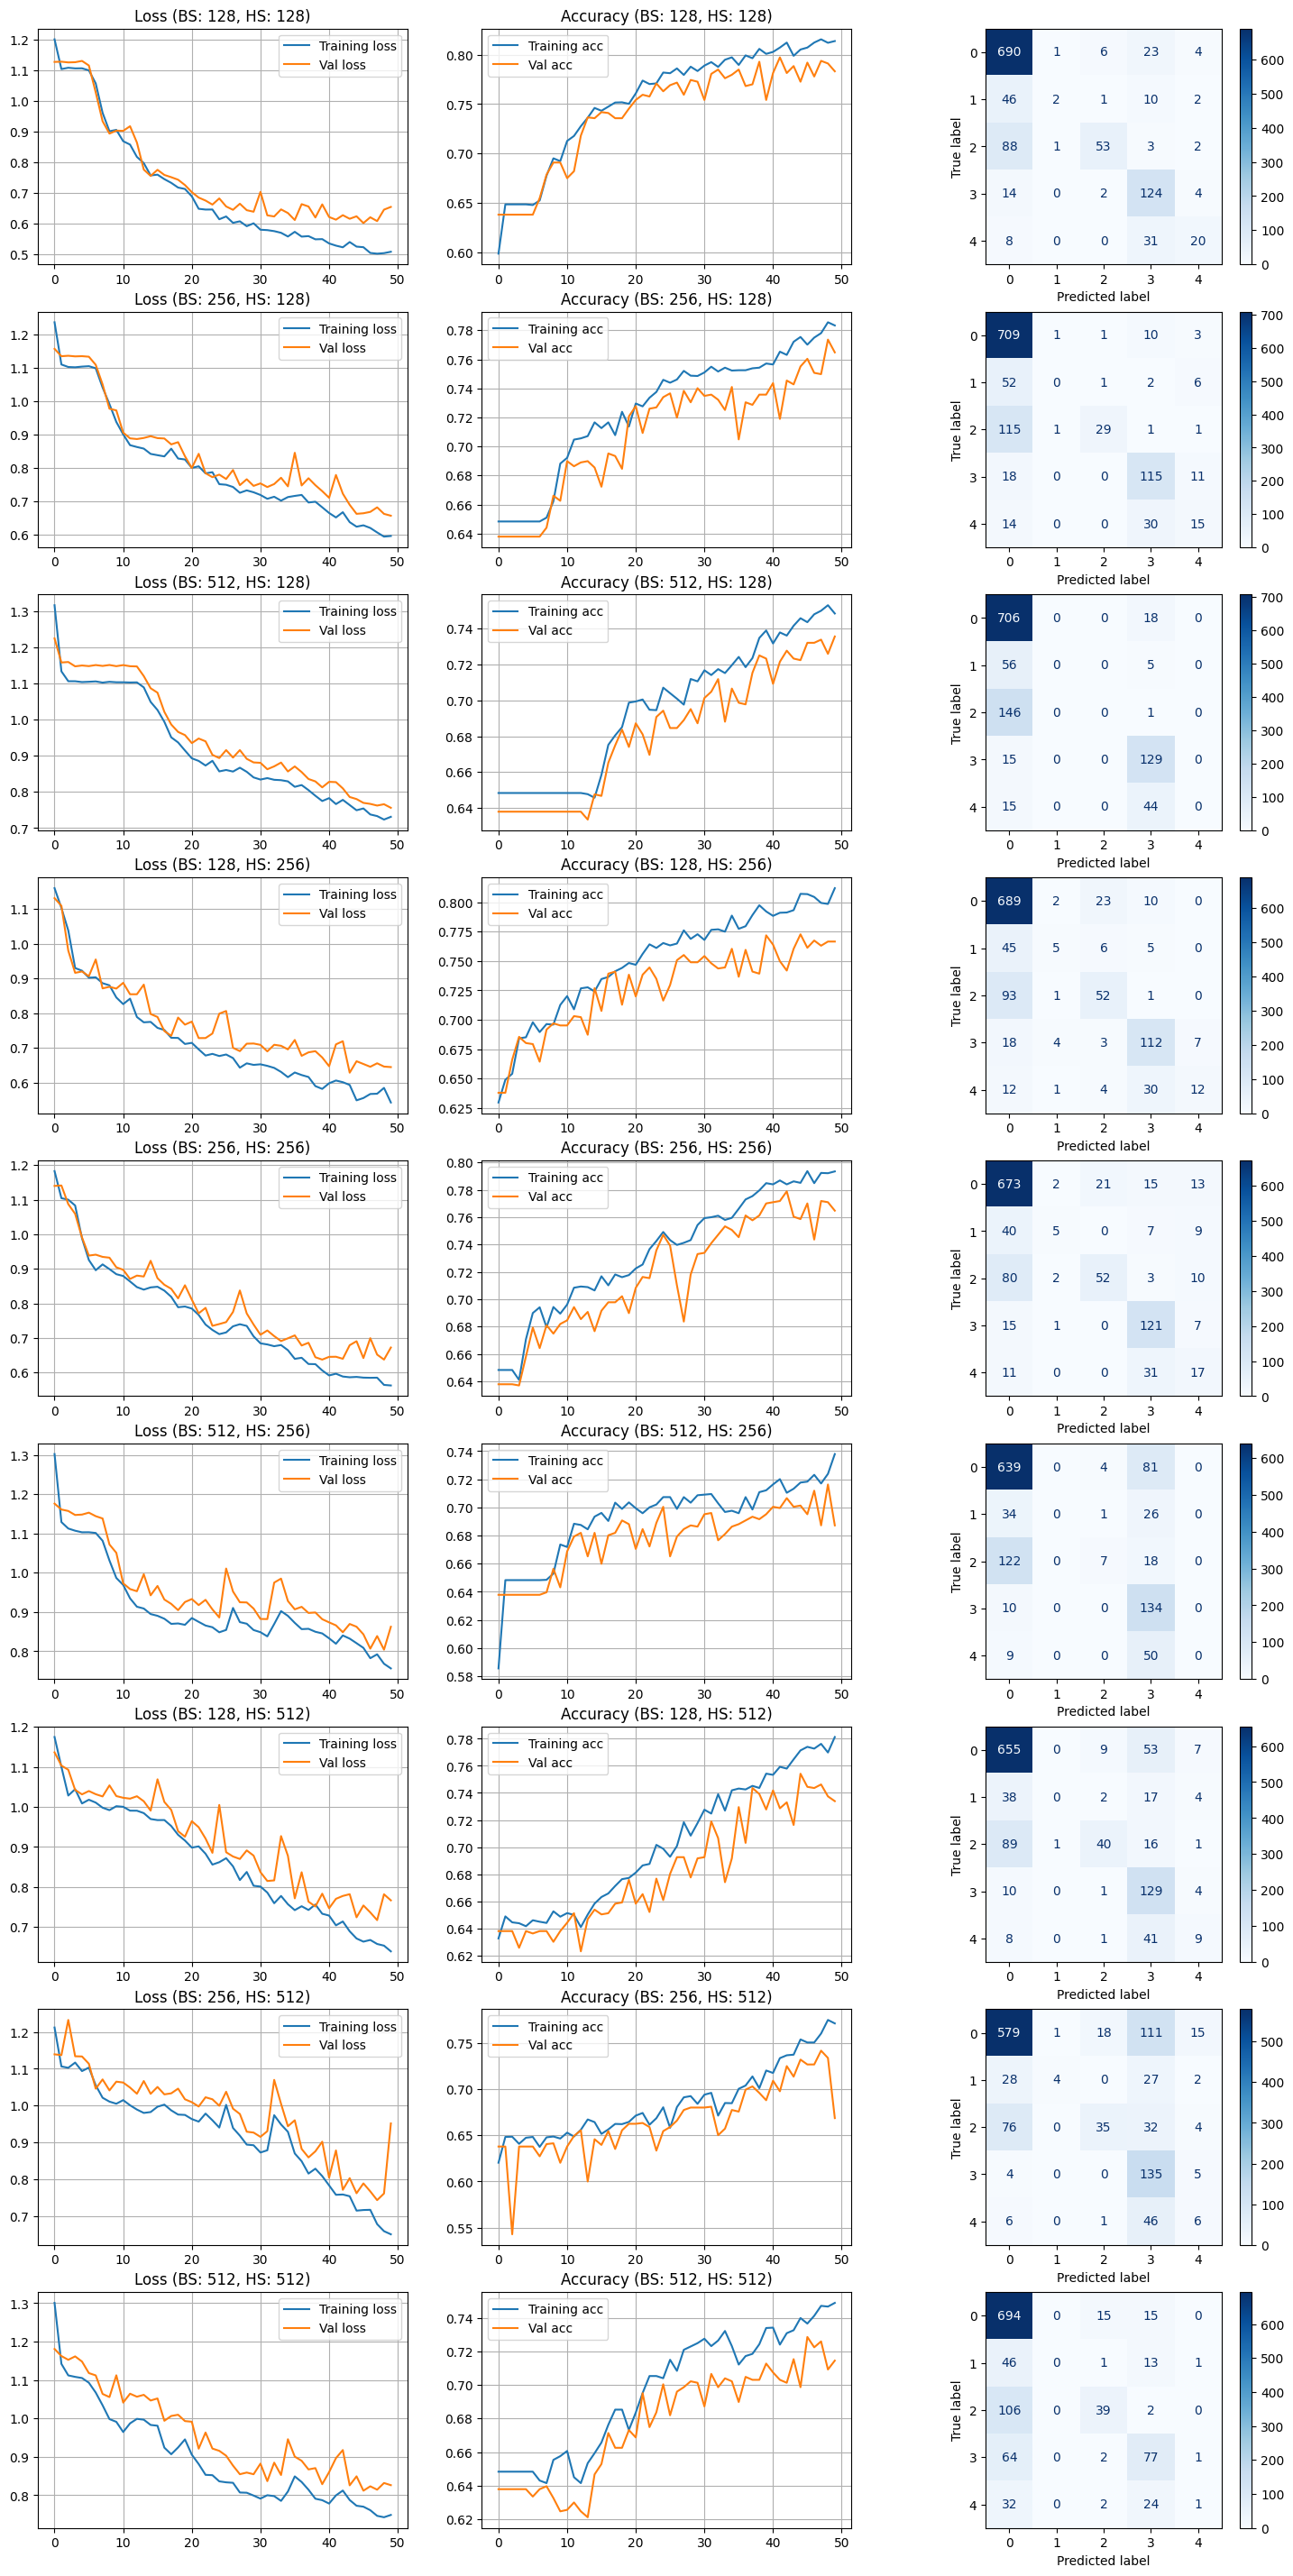

In [26]:
settings = [
    {
        'hidden_size': 128,
        'batch_size': 128,
    },
    {
        'hidden_size': 128,
        'batch_size': 256,
    },
    {
        'hidden_size': 128,
        'batch_size': 512,
    },
    {
        'hidden_size': 256,
        'batch_size': 128,
    },
    {
        'hidden_size': 256,
        'batch_size': 256,
    },
    {
        'hidden_size': 256,
        'batch_size': 512,
    },
    {
        'hidden_size': 512,
        'batch_size': 128,
    },
    {
        'hidden_size': 512,
        'batch_size': 256,
    },
    {
        'hidden_size': 512,
        'batch_size': 512,
    }
]

num_epochs = 50
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))

for i, setting in enumerate(settings):
    batch_size = setting['batch_size']
    hidden_size = setting['hidden_size']
    print(f"Run {i+1} with batch_size {batch_size} and hidden_size {hidden_size}.")

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Create Model
    model = RNNClassifier(input_size=len_alphabet, hidden_size=hidden_size, output_size=len(languages)).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, val_loader, optimizer, criterion, num_epochs, verbose=False)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss (BS: {batch_size}, HS: {hidden_size})")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy (BS: {batch_size}, HS: {hidden_size})")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

#### Findings

Without looking at the confusion matrix, all different combinations seem to be performing rather good with no evidence of overfitting. However, the look at the confusion matrix shows that there is an imbalance in the data leading to that misleading result. This shows that just a look at the loss and the accuracy can lead to wrong conclusions without knowing the big picture.

### Implement Model with several SimpleRNN Layers

As the results before to not really vary between the different settings, we will go with Batchsize 256 and hidden size 256 here and just try out different number of layers to compare those.

Run 1 with 2 Layers.
Train Loss: 1.1671, Train Accuracy: 0.6155
Val Loss: 1.1351, Val Accuracy: 0.6379
Train Loss: 0.8552, Train Accuracy: 0.7111
Val Loss: 0.8732, Val Accuracy: 0.6934
Train Loss: 0.7315, Train Accuracy: 0.7412
Val Loss: 0.7695, Val Accuracy: 0.7233
Train Loss: 0.6633, Train Accuracy: 0.7648
Val Loss: 0.7632, Val Accuracy: 0.7260
Train Loss: 0.6158, Train Accuracy: 0.7829
Val Loss: 0.7589, Val Accuracy: 0.7207
Run 2 with 4 Layers.
Train Loss: 1.1587, Train Accuracy: 0.6151
Val Loss: 1.1433, Val Accuracy: 0.6379
Train Loss: 0.7468, Train Accuracy: 0.7441
Val Loss: 0.7599, Val Accuracy: 0.7348
Train Loss: 0.6880, Train Accuracy: 0.7666
Val Loss: 0.7131, Val Accuracy: 0.7515
Train Loss: 0.6075, Train Accuracy: 0.7895
Val Loss: 0.7135, Val Accuracy: 0.7533
Train Loss: 0.5393, Train Accuracy: 0.8075
Val Loss: 0.6866, Val Accuracy: 0.7709
Run 3 with 6 Layers.
Train Loss: 1.1716, Train Accuracy: 0.6203
Val Loss: 1.1389, Val Accuracy: 0.6379
Train Loss: 0.9401, Train Accuracy:

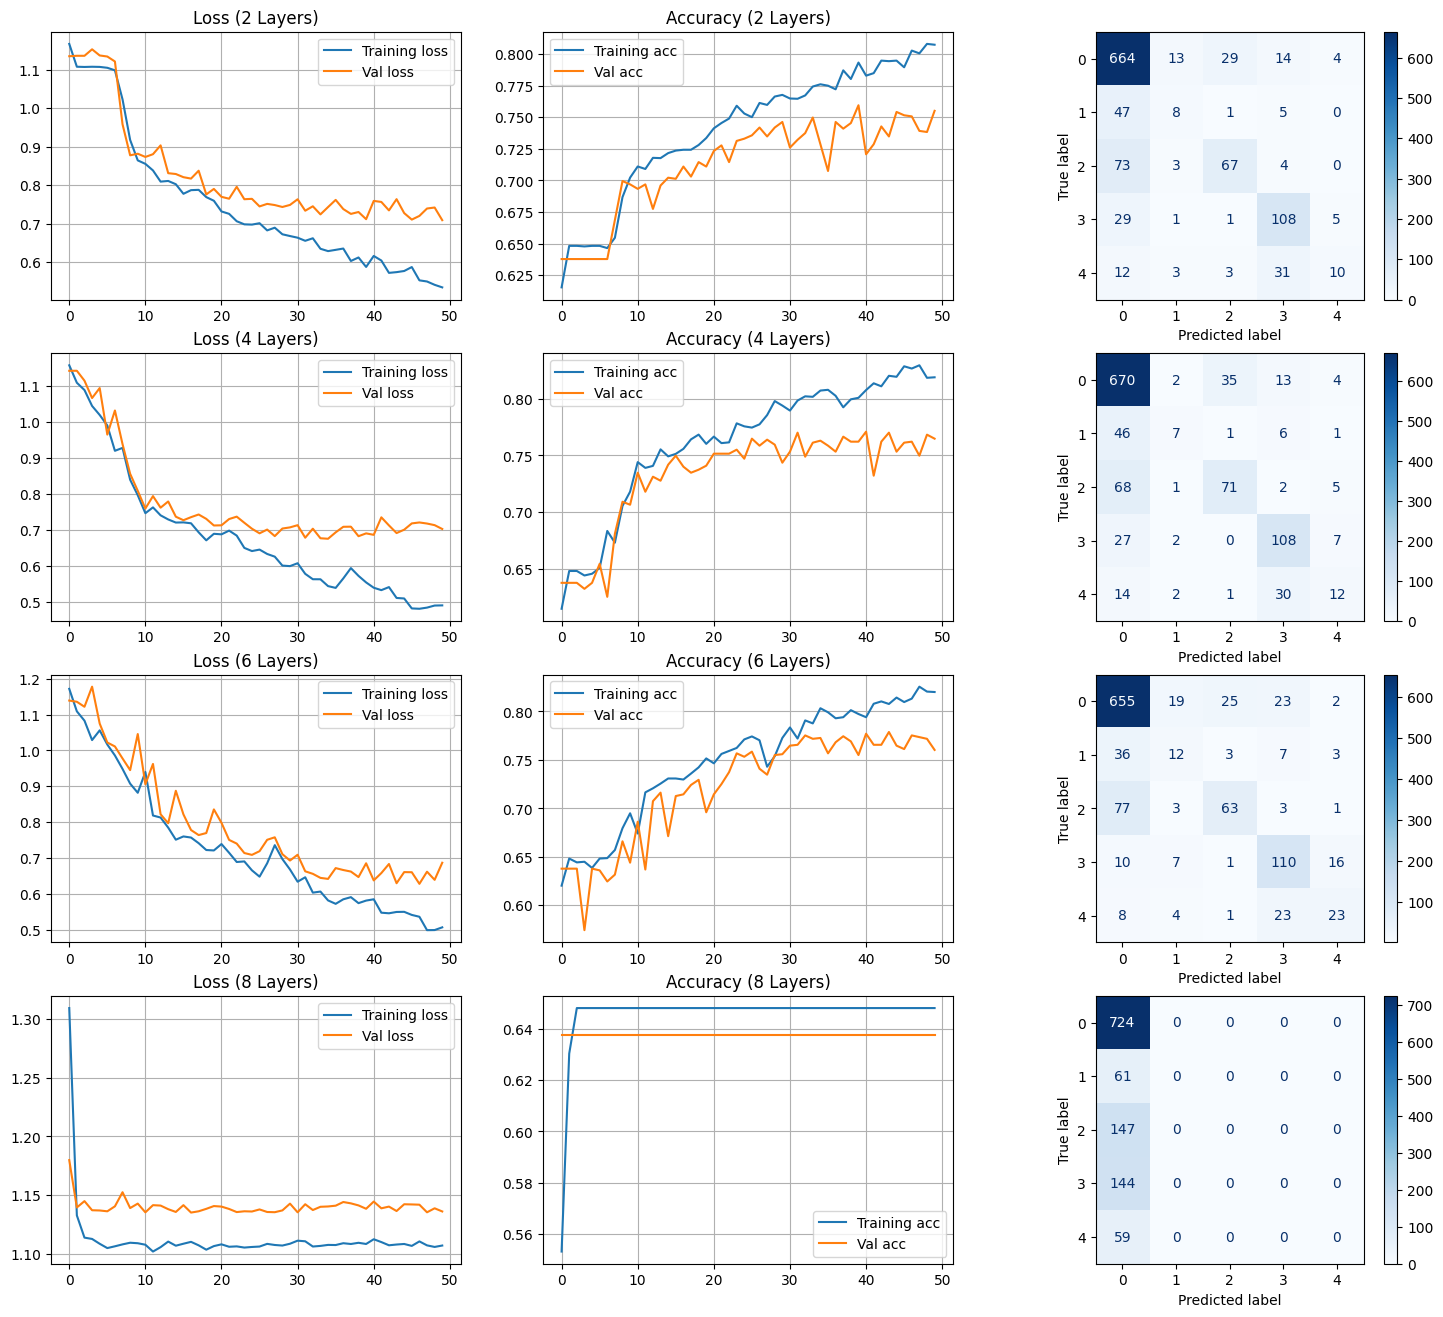

In [28]:
settings = [
    {
        'num_layers': 2
    },
    {
        'num_layers': 4
    },
    {
        'num_layers': 6
    },
    {
        'num_layers': 8
    }
]

# Create DataLoaders (outside of loop as we fix the batch-size in this experiment
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

num_epochs = 50
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))

for i, setting in enumerate(settings):
    num_layers = setting['num_layers']
    print(f"Run {i+1} with {num_layers} Layers.")

    # Create Model
    model = RNNClassifier(input_size=len_alphabet, hidden_size=256, output_size=len(languages), num_layers=num_layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, val_loader, optimizer, criterion, num_epochs, verbose=False)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss ({num_layers} Layers)")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy ({num_layers} Layers)")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

#### Findings

Same picture here, with more layers leading to even more imbalanced predictions. (8 Layers predicts just 0).

### Class Imbalance Handling

Choose a method to address the class imbalance seen in the given example.
- minority resampling 
- class weights in the loss

Implement it and incorporate it in the training.
Evaluate the results and compare it with the results obtained with the unbalanced training.  

In [29]:
from sklearn.utils import resample

In [30]:
names = load_data(srcdir,categories=languages)

names['lang'].value_counts()

lang
English    3668
German      724
Italian     709
Spanish     298
French      277
Name: count, dtype: int64

In [31]:
# Reload the data
names = load_data(srcdir,categories=languages)

names = names.sample(frac=1, random_state=42).reset_index(drop=True)
max_class_size = names['lang'].value_counts().max()


balanced_names = []

for label in names['lang'].unique():
    class_subset = names[names['lang'] == label]
    upsampled = resample(
        class_subset,
        replace=True,
        n_samples=max_class_size,
        random_state=42
    )
    balanced_names.append(upsampled)

names_balanced = pd.concat(balanced_names).sample(frac=1, random_state=42).reset_index(drop=True)

names_balanced.groupby('lang')['name'].count()/len(names_balanced)

lang
English    0.2
French     0.2
German     0.2
Italian    0.2
Spanish    0.2
Name: name, dtype: float64

In [32]:
names_balanced['lang'] = names_balanced['lang'].apply(lambda x: lang_representation(x, language_to_index))
names_balanced['name'] = names_balanced['name'].apply(lambda x: name_representation(x, maxlen))

# Split into train and val
val_size = int(len(names_balanced) * val_split)
val = names_balanced[:val_size]
train = names_balanced[val_size:]

# Map train and val data into vector space (one-hot-vectors)
X_train = torch.tensor(train['name'].tolist(), dtype=torch.float32)
y_train = torch.tensor(train['lang'].tolist(), dtype=torch.float32)

X_val = torch.tensor(val['name'].tolist(), dtype=torch.float32)
y_val = torch.tensor(val['lang'].tolist(), dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

Run 1 with 2 Layers.
Train Loss: 1.5371, Train Accuracy: 0.2650
Val Loss: 1.2919, Val Accuracy: 0.4152
Train Loss: 0.5288, Train Accuracy: 0.7955
Val Loss: 0.5009, Val Accuracy: 0.8198
Train Loss: 0.2162, Train Accuracy: 0.9252
Val Loss: 0.2347, Val Accuracy: 0.9218
Train Loss: 0.1396, Train Accuracy: 0.9500
Val Loss: 0.1833, Val Accuracy: 0.9419
Train Loss: 0.0976, Train Accuracy: 0.9629
Val Loss: 0.1899, Val Accuracy: 0.9417
Run 2 with 2 Layers.
Train Loss: 1.5740, Train Accuracy: 0.2602
Val Loss: 1.4571, Val Accuracy: 0.3648
Train Loss: 0.5320, Train Accuracy: 0.7953
Val Loss: 0.5014, Val Accuracy: 0.8119
Train Loss: 0.1635, Train Accuracy: 0.9410
Val Loss: 0.1892, Val Accuracy: 0.9395
Train Loss: 0.1041, Train Accuracy: 0.9616
Val Loss: 0.1490, Val Accuracy: 0.9479
Train Loss: 0.0792, Train Accuracy: 0.9688
Val Loss: 0.1498, Val Accuracy: 0.9463
Run 3 with 2 Layers.
Train Loss: 1.6111, Train Accuracy: 0.2007
Val Loss: 1.5820, Val Accuracy: 0.2713
Train Loss: 0.7877, Train Accuracy:

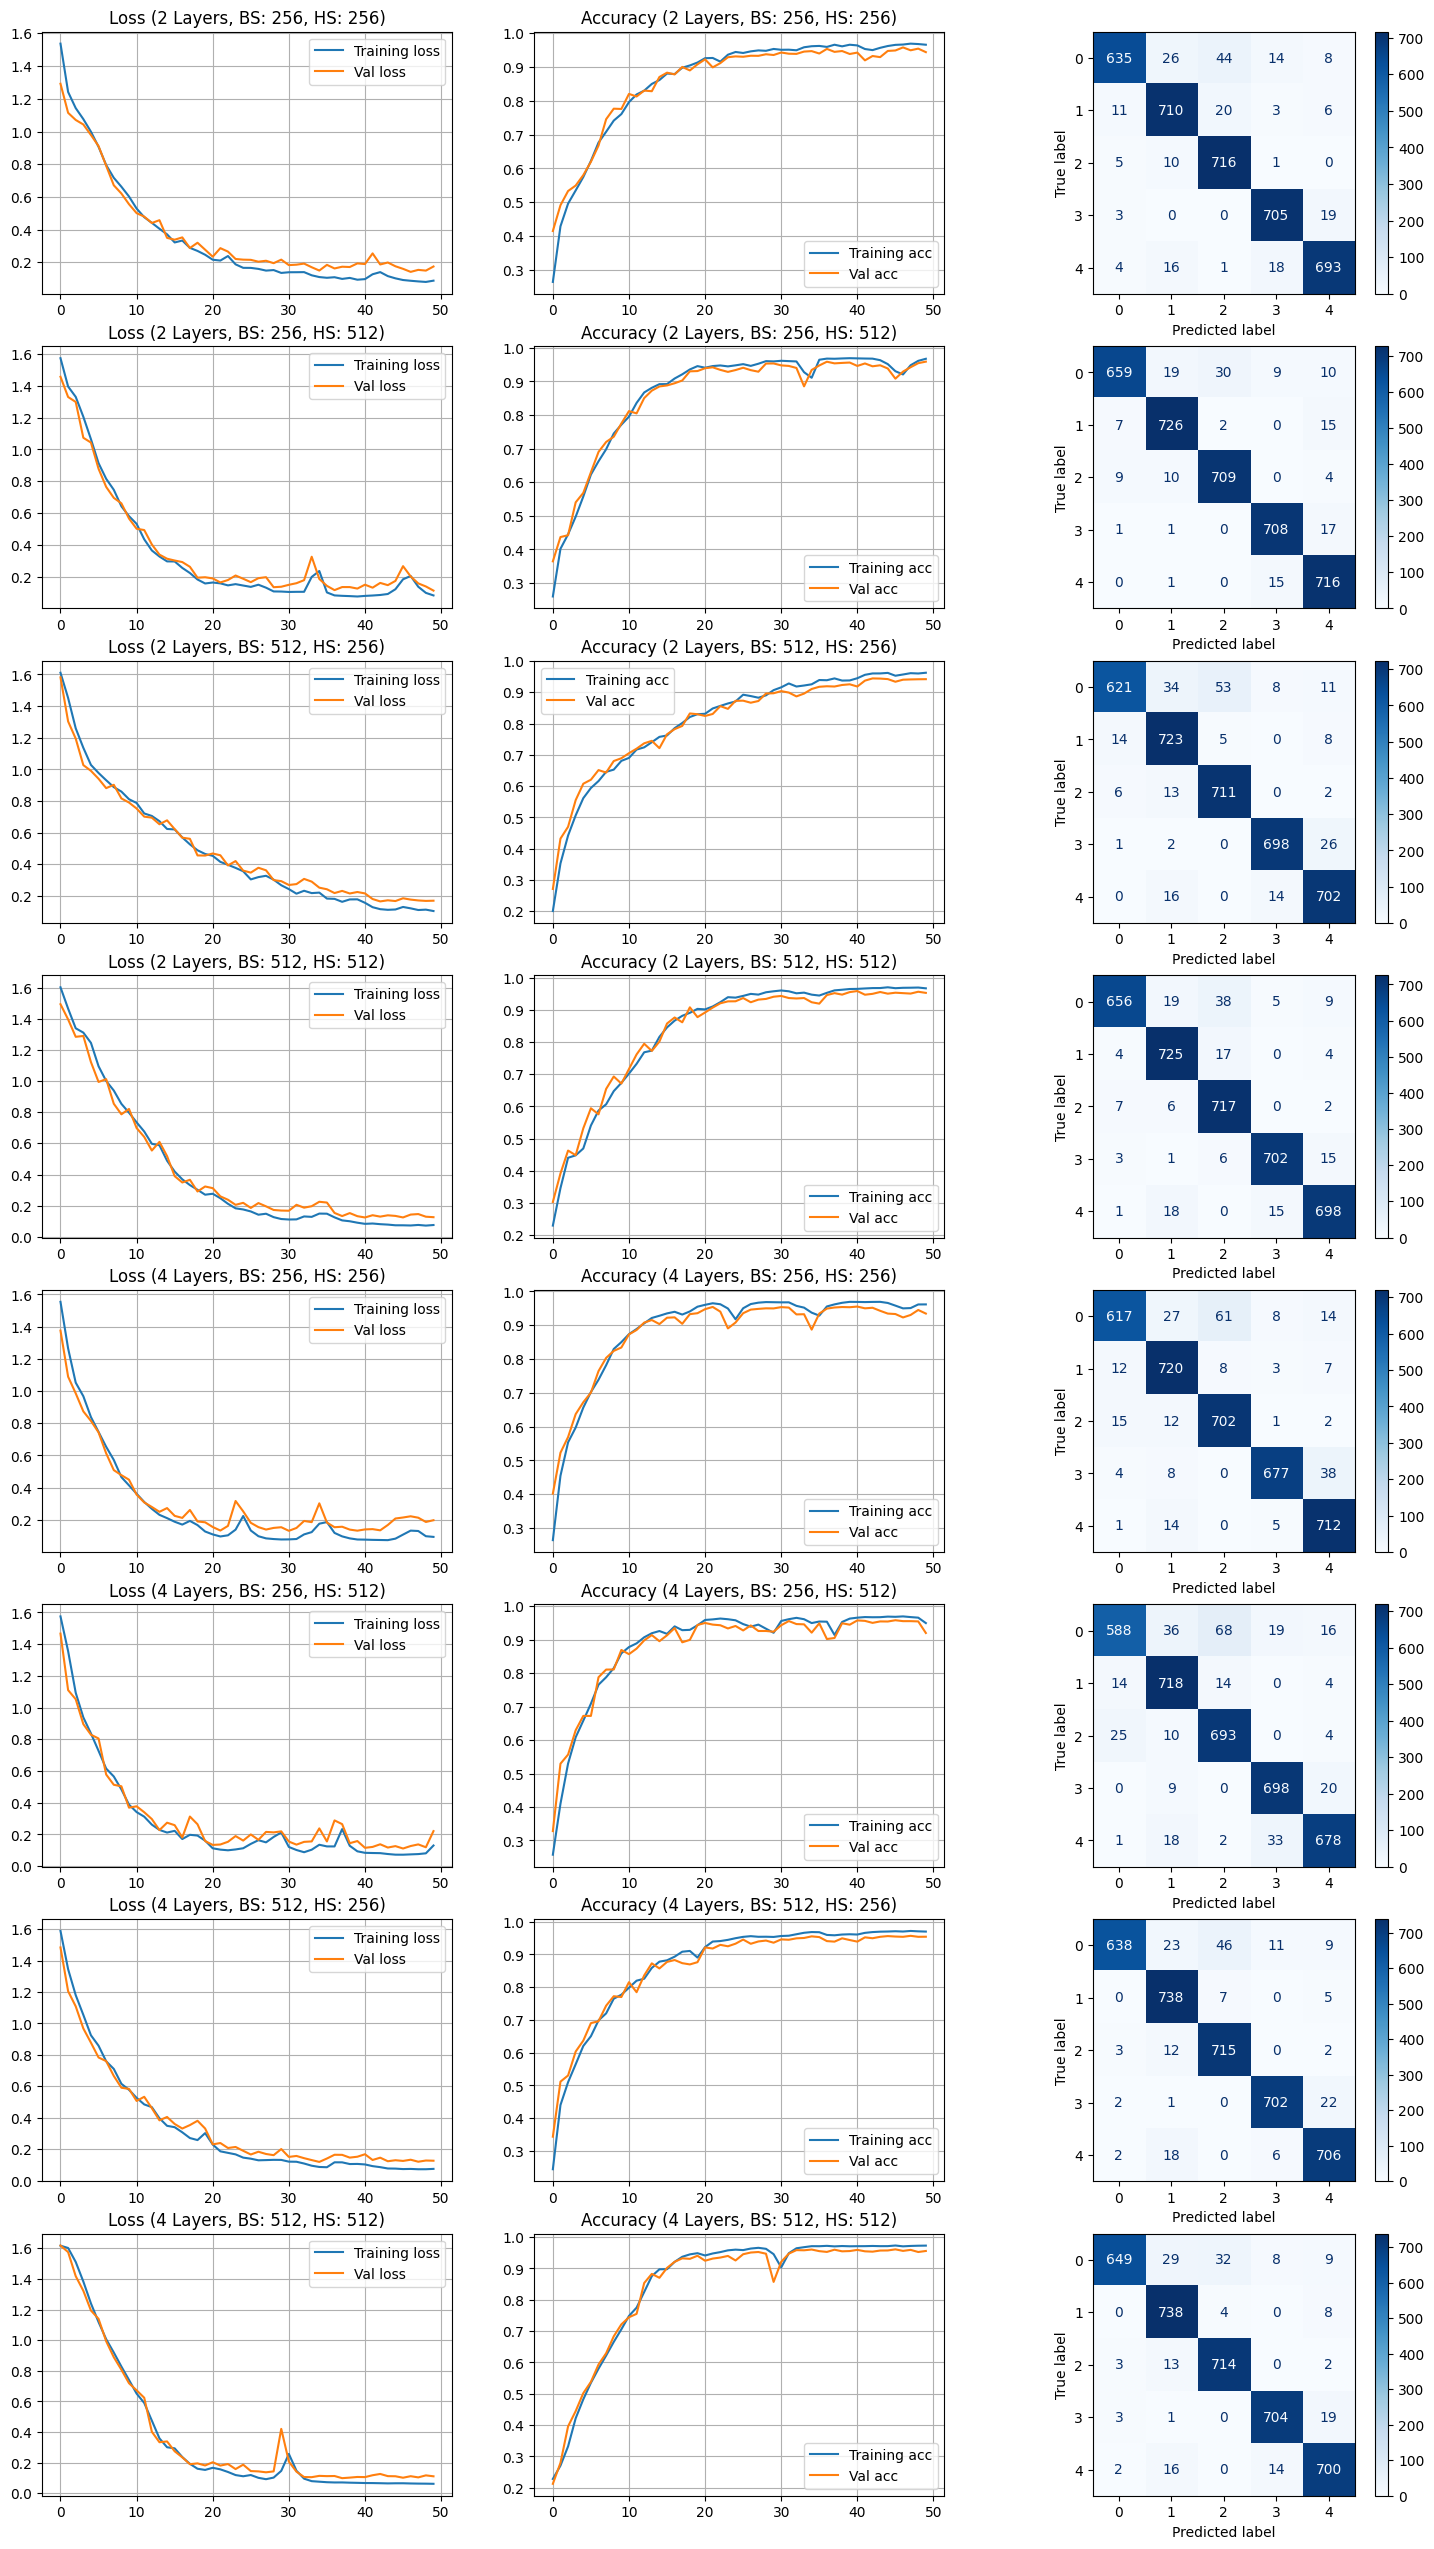

In [33]:
settings = [
    {
        'num_layers': 2,
        'batch_size': 256,
        'hidden_size': 256,
    },
    {
        'num_layers': 2,
        'batch_size': 256,
        'hidden_size': 512,
    },
    {
        'num_layers': 2,
        'batch_size': 512,
        'hidden_size': 256,
    },
    {
        'num_layers': 2,
        'batch_size': 512,
        'hidden_size': 512,
    },
    {
        'num_layers': 4,
        'batch_size': 256,
        'hidden_size': 256,
    },
    {
        'num_layers': 4,
        'batch_size': 256,
        'hidden_size': 512,
    },
    {
        'num_layers': 4,
        'batch_size': 512,
        'hidden_size': 256,
    },
    {
        'num_layers': 4,
        'batch_size': 512,
        'hidden_size': 512,
    }
]


num_epochs = 50
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))

for i, setting in enumerate(settings):
    num_layers = setting['num_layers']
    batch_size = setting['batch_size']
    hidden_size = setting['hidden_size']
    print(f"Run {i+1} with {num_layers} Layers.")

    # Create DataLoaders (outside of loop as we fix the batch-size in this experiment
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Create Model
    model = RNNClassifier(input_size=len_alphabet, hidden_size=hidden_size, output_size=len(languages), num_layers=num_layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, val_loader, optimizer, criterion, num_epochs, verbose=False)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss ({num_layers} Layers, BS: {batch_size}, HS: {hidden_size})")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy ({num_layers} Layers, BS: {batch_size}, HS: {hidden_size})")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

# Comments
Looks much better now. No more one-sided predictions, but even results across all classes with a loss of close to zero and an accuracy of almost 100%.